# 05 — SHAP Explainability

Answers: *why* did the churn/CLV model produce this prediction for a particular customer?

- **Global explanation** — which features generally influence the model across all customers.
- **Local explanation** — which features influenced one specific customer's prediction.

SHAP values are kept as **structured data** (not just plots or text), so Notebook 7's LLM narration component can consume them directly.

> **Research limitation, stated explicitly here because it matters for the paper**: SHAP is treated as **associational / model-explanatory, not causal**. `avg_freight` having a positive SHAP contribution means the *model* leaned on that feature to raise its prediction for this customer — it does **not** mean reducing freight cost would reduce that customer's actual churn risk. That distinction should appear wherever these results are discussed.

In [1]:

from google.colab import drive
drive.mount('/content/drive')

!pip install -q duckdb pandas pyarrow scikit-learn xgboost lightgbm mlxtend shap prophet google-genai

from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Ecommerce-AI-Business-Intelligence")
DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_DIR = PROCESSED_DIR / "features"
MODELS_DIR = PROCESSED_DIR / "models"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
WAREHOUSE_PATH = PROJECT_ROOT / "warehouse.duckdb"

for d in [PROCESSED_DIR, FEATURES_DIR, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Mounted at /content/drive
Project root: /content/drive/MyDrive/Colab Notebooks/Ecommerce-AI-Business-Intelligence


## Rebuild the churn model

Notebook 4 didn't persist the fitted model object, only its predictions — so, consistent with how every other notebook in this project reloads from Drive rather than depending on in-memory state from a prior notebook, this retrains the identical model here (same features, same `random_state=42`, same hyperparameters) rather than introducing a joblib dependency between notebooks. If you'd rather persist the model once and load it everywhere, add `joblib.dump(xgb_churn, MODELS_DIR / 'churn_model.joblib')` to the end of Notebook 4 and swap this cell for a `joblib.load(...)` call.

In [2]:

import duckdb, pandas as pd

# --- churn window (identical derivation to Notebook 4) ---
con = duckdb.connect(str(WAREHOUSE_PATH))
gap_query = """
SELECT c.customer_unique_id, d.full_date AS order_date
FROM fact_order_item f
JOIN dim_customer c ON f.customer_key = c.customer_key
JOIN dim_date d ON f.order_date_key = d.date_key
"""
order_dates = con.execute(gap_query).df()
con.close()
order_dates["order_date"] = pd.to_datetime(order_dates["order_date"])
order_dates = order_dates.drop_duplicates(subset=["customer_unique_id", "order_date"]).sort_values(
    ["customer_unique_id", "order_date"])
order_dates["gap_days"] = order_dates.groupby("customer_unique_id")["order_date"].diff().dt.days
CHURN_WINDOW_DAYS = int(round(order_dates["gap_days"].dropna().quantile(0.90)))

# --- features + labels ---
customer_features = pd.read_parquet(FEATURES_DIR / "customer_features.parquet")
segments = pd.read_parquet(MODELS_DIR / "customer_segments.parquet")[["customer_unique_id", "segment_id"]]
df = customer_features.merge(segments, on="customer_unique_id", how="inner")
df["churned"] = (df["recency_days"] > CHURN_WINDOW_DAYS).astype(int)

NULLABLE_FEATURES = ["avg_review_score", "avg_delivery_days", "avg_delivery_delay"]

def build_feature_matrix(df, drop_extra=()):
    drop_cols = ["customer_unique_id", "recency_days", "first_purchase", "last_purchase",
                 "churned", "segment_id"] + list(drop_extra)
    X = df[[c for c in df.columns if c not in drop_cols]].copy()
    for col in NULLABLE_FEATURES:
        X[f"{col}_missing"] = X[col].isna().astype(int)
        X[col] = X[col].fillna(X[col].median())
    X = pd.get_dummies(X, columns=["customer_state"], prefix="state")
    return X

X_churn = build_feature_matrix(df)
y_churn = df["churned"]

# --- retrain the same XGBoost churn model as Notebook 4 ---
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_churn, y_churn, df.index, test_size=0.2, random_state=42, stratify=y_churn)
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
xgb_churn = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                           scale_pos_weight=scale_pos_weight, eval_metric="logloss", random_state=42)
xgb_churn.fit(X_train, y_train)
df["churn_probability"] = xgb_churn.predict_proba(X_churn)[:, 1]
print(f"Rebuilt churn model on {len(df):,} customers, churn_window={CHURN_WINDOW_DAYS}d")


Rebuilt churn model on 95,420 customers, churn_window=280d


## Global explanation

Which features generally drive the churn model's predictions, across all customers?

,feature,mean_abs_shap
0,avg_freight,0.546510
1,avg_delivery_delay,0.208159
2,avg_delivery_days,0.176444
3,avg_installments,0.096227
4,state_SP,0.073309
5,avg_order_value,0.044306
6,monetary,0.044182
7,customer_tenure_days,0.029820
8,state_RJ,0.029404
9,state_MG,0.020947


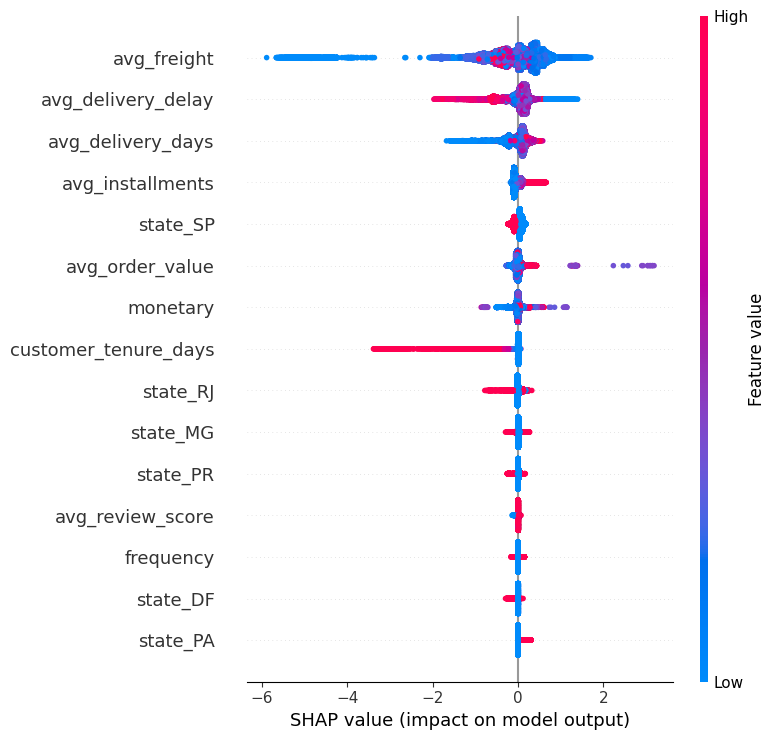

In [3]:

import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_churn)
shap_values = explainer.shap_values(X_churn)

global_importance = (pd.DataFrame({"feature": X_churn.columns, "mean_abs_shap": abs(shap_values).mean(axis=0)})
                      .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
display(global_importance.head(15))

shap.summary_plot(shap_values, X_churn, show=False, max_display=15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_churn_summary.png", dpi=110, bbox_inches="tight")
plt.show()

global_importance.to_parquet(MODELS_DIR / "shap_churn_global_importance.parquet", index=False)


## Local (per-customer) explanations

One row per (customer, feature) — the shape Notebook 7 needs to ground narration in specific evidence. Kept for every customer at the top-K most influential features per customer, rather than every feature for every customer, to keep this table a manageable size.

In [4]:

TOP_K_FEATURES_PER_CUSTOMER = 8

shap_long_rows = []
customer_ids = df["customer_unique_id"].values
feature_names = X_churn.columns.to_numpy()
X_values = X_churn.to_numpy()

for i in range(len(df)):
    row_shap = shap_values[i]
    top_idx = abs(row_shap).argsort()[::-1][:TOP_K_FEATURES_PER_CUSTOMER]
    for j in top_idx:
        shap_long_rows.append({
            "customer_unique_id": customer_ids[i],
            "feature": feature_names[j],
            "feature_value": X_values[i, j],
            "shap_value": row_shap[j],
            "direction": "increases_churn_prediction" if row_shap[j] > 0 else "decreases_churn_prediction",
        })

shap_customer_explanations = pd.DataFrame(shap_long_rows)
shap_customer_explanations.to_parquet(MODELS_DIR / "shap_churn_customer_explanations.parquet", index=False)
print(f"Saved {len(shap_customer_explanations):,} (customer, feature) rows for "
      f"{shap_customer_explanations['customer_unique_id'].nunique():,} customers")


Saved 763,360 (customer, feature) rows for 95,420 customers


In [5]:

# Example: what does this look like for one customer? (matches the style used in the paper's
# methodology section, e.g. "avg_freight -> increases churn prediction")
example_customer = customer_ids[0]
example = shap_customer_explanations[shap_customer_explanations["customer_unique_id"] == example_customer]
print(f"Top drivers for customer {example_customer} "
      f"(churn_probability={df.loc[df.customer_unique_id == example_customer, 'churn_probability'].iat[0]:.2f}):")
for _, r in example.sort_values("shap_value", key=abs, ascending=False).iterrows():
    arrow = "increases" if r["shap_value"] > 0 else "decreases"
    print(f"  {r['feature']:28s} = {r['feature_value']:<10.2f} -> {arrow} churn prediction "
          f"(shap={r['shap_value']:+.4f})")


Top drivers for customer 0000366f3b9a7992bf8c76cfdf3221e2 (churn_probability=0.26):
  avg_delivery_delay           = -5.00      -> decreases churn prediction (shap=-0.8356)
  avg_delivery_days            = 6.00       -> decreases churn prediction (shap=-0.6046)
  avg_freight                  = 12.00      -> increases churn prediction (shap=+0.5427)
  avg_installments             = 8.00       -> decreases churn prediction (shap=-0.0480)
  monetary                     = 141.90     -> decreases churn prediction (shap=-0.0455)
  state_SP                     = 1.00       -> decreases churn prediction (shap=-0.0385)
  avg_order_value              = 141.90     -> decreases churn prediction (shap=-0.0372)
  state_RJ                     = 0.00       -> decreases churn prediction (shap=-0.0143)


## SHAP for the CLV regressor

Shorter pass — global importance only, since the churn explanation above is the one the narration layer leans on most heavily.

In [6]:

clv_predictions = pd.read_parquet(MODELS_DIR / "clv_predictions.parquet")
X_clv = build_feature_matrix(df, drop_extra=["monetary"])
X_clv["churn_probability"] = df["churn_probability"].values

from lightgbm import LGBMRegressor
lgbm_clv = LGBMRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42, verbose=-1)
lgbm_clv.fit(X_clv, df["monetary"])

clv_explainer = shap.TreeExplainer(lgbm_clv)
clv_shap_values = clv_explainer.shap_values(X_clv)

clv_global_importance = (pd.DataFrame({"feature": X_clv.columns,
                                        "mean_abs_shap": abs(clv_shap_values).mean(axis=0)})
                          .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
display(clv_global_importance.head(15))
clv_global_importance.to_parquet(MODELS_DIR / "shap_clv_global_importance.parquet", index=False)


,feature,mean_abs_shap
0,avg_order_value,113.278794
1,frequency,9.612221
2,avg_freight,0.946008
3,churn_probability,0.638712
4,avg_delivery_days,0.563976
5,avg_delivery_delay,0.468533
6,avg_installments,0.443470
7,state_RJ,0.254527
8,avg_review_score,0.227512
9,state_SP,0.128561


---
### Outputs from this notebook
- `shap_churn_global_importance.parquet` — ranked features, whole population
- `shap_churn_customer_explanations.parquet` — top-8 SHAP-ranked features per customer
- `shap_clv_global_importance.parquet` — ranked features for the CLV regressor
- `reports/figures/shap_churn_summary.png`